# Caspase-1 Inflammasome Axis Analysis in Acne Vulgaris

This notebook performs biophysical characterization, inferential statistical testing, regression modeling, and multi-technique clustering on AlphaFold structures for six enzymes in the acne vulgaris inflammatory axis. It evaluates structural confidence, solvent accessibility determinants, and conserved residue micro-environments across destructive and regulatory targets.

### Step 1: Configure dependencies and environment settings

In [1]:
import os
import sys
import json
import warnings
import urllib.request
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import Bio.PDB
from Bio.PDB import PDBParser, ShrakeRupley

try:
    import py3Dmol
    HAS_PY3DMOL = True
except ImportError:
    HAS_PY3DMOL = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "figure.autolayout": True
})

DATA_DIR = os.path.join(".", "data", "alphafold_cache")
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Caching directory configured at: {os.path.abspath(DATA_DIR)}")

Caching directory configured at: C:\Users\thoma\alphafold-confidence-project\acne\data\alphafold_cache


### Step 2: Ingest AlphaFold structural coordinates and predicted aligned error data

In [2]:
TARGET_REGISTRY = {
    "CASP1": {
        "uniprot_id": "P29466",
        "name": "Caspase-1",
        "role": "Inflammasome Core Peptidase"
    },
    "MMP1": {
        "uniprot_id": "P03956",
        "name": "Matrix Metalloproteinase-1",
        "role": "Collagenase / Tissue Remodeling"
    },
    "ELANE": {
        "uniprot_id": "P08246",
        "name": "Neutrophil Elastase",
        "role": "Acute Proteolysis"
    },
    "PTGS2": {
        "uniprot_id": "P35354",
        "name": "Cyclooxygenase-2 (COX-2)",
        "role": "Prostaglandin Synthase"
    },
    "RIPK1": {
        "uniprot_id": "Q13546",
        "name": "Receptor-Interacting Kinase 1",
        "role": "Pyroptosis/Necroptosis Switch"
    },
    "TNFAIP3": {
        "uniprot_id": "P21580",
        "name": "Zinc Finger Protein A20",
        "role": "Anti-inflammatory Deubiquitinase"
    }
}


def fetch_alphafold_data(uniprot_id: str, out_dir: str = DATA_DIR) -> dict:
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    pdb_path = os.path.join(out_dir, f"{uniprot_id}.pdb")
    pae_path = os.path.join(out_dir, f"{uniprot_id}_pae.json")
    meta_path = os.path.join(out_dir, f"{uniprot_id}_meta.json")

    headers = {"User-Agent": "BioinformaticsResearch-Caspase1-Acne/1.0"}

    # Use local cache if available
    if os.path.exists(pdb_path) and os.path.exists(pae_path):
        return {"uniprot_id": uniprot_id, "pdb_path": pdb_path, "pae_path": pae_path}

    response = requests.get(api_url, headers=headers, timeout=30)
    response.raise_for_status()
    payload = response.json()

    if not payload or not isinstance(payload, list):
        raise ValueError(f"No prediction record returned for UniProt accession: {uniprot_id}")

    prediction = payload[0]
    pdb_url = prediction.get("pdbUrl")
    pae_url = prediction.get("paeDocUrl")

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(prediction, f, indent=2)

    if pdb_url and not os.path.exists(pdb_path):
        r_pdb = requests.get(pdb_url, headers=headers, timeout=60)
        r_pdb.raise_for_status()
        with open(pdb_path, "w", encoding="utf-8") as f:
            f.write(r_pdb.text)

    if pae_url and not os.path.exists(pae_path):
        r_pae = requests.get(pae_url, headers=headers, timeout=60)
        r_pae.raise_for_status()
        with open(pae_path, "w", encoding="utf-8") as f:
            f.write(r_pae.text)

    return {"uniprot_id": uniprot_id, "pdb_path": pdb_path, "pae_path": pae_path}

In [3]:
dataset_manifest = {}
for symbol, meta in TARGET_REGISTRY.items():
    paths = fetch_alphafold_data(meta["uniprot_id"], DATA_DIR)
    dataset_manifest[symbol] = {**meta, **paths}
    print(f"Verified {symbol} ({meta['uniprot_id']}): PDB={os.path.basename(paths['pdb_path'])}, PAE={os.path.basename(paths['pae_path'])}")

Verified CASP1 (P29466): PDB=P29466.pdb, PAE=P29466_pae.json
Verified MMP1 (P03956): PDB=P03956.pdb, PAE=P03956_pae.json
Verified ELANE (P08246): PDB=P08246.pdb, PAE=P08246_pae.json
Verified PTGS2 (P35354): PDB=P35354.pdb, PAE=P35354_pae.json
Verified RIPK1 (Q13546): PDB=Q13546.pdb, PAE=Q13546_pae.json
Verified TNFAIP3 (P21580): PDB=P21580.pdb, PAE=P21580_pae.json


### Step 3: Extract per-residue biophysical and geometric features

In [4]:
# Amino acid dictionary mapping
AA_3TO1 = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F",
    "GLY": "G", "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L",
    "MET": "M", "ASN": "N", "PRO": "P", "GLN": "Q", "ARG": "R",
    "SER": "S", "THR": "T", "VAL": "V", "TRP": "W", "TYR": "Y"
}

# Kyte-Doolittle hydropathy scale
KYTE_DOOLITTLE = {
    "I": 4.5, "V": 4.2, "L": 3.8, "F": 2.8, "C": 2.5, "M": 1.9, "A": 1.8,
    "G": -0.4, "T": -0.7, "S": -0.8, "W": -0.9, "Y": -1.3, "P": -1.6,
    "H": -3.2, "E": -3.5, "Q": -3.5, "D": -3.5, "N": -3.5, "K": -3.9, "R": -4.5
}

# Net formal electric charge at physiological pH 7.4
FORMAL_CHARGE_PH74 = {
    "ARG": 1.0,
    "LYS": 1.0,
    "HIS": 0.1,
    "ASP": -1.0,
    "GLU": -1.0
}

In [5]:
def extract_protein_features(symbol: str, meta: dict) -> pd.DataFrame:
    pdb_path = meta["pdb_path"]
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(symbol, pdb_path)
    model = structure[0]

    # Calculate Solvent Accessible Surface Area with probe radius 1.4 A
    sr = ShrakeRupley(probe_radius=1.4, n_points=100)
    sr.compute(model, level="R")

    # Compute center of mass across C-alpha atoms
    ca_coords = []
    for chain in model:
        for res in chain:
            if Bio.PDB.is_aa(res) and "CA" in res:
                ca_coords.append(res["CA"].get_coord())

    if not ca_coords:
        raise ValueError(f"No C-alpha atoms identified in PDB for {symbol}")

    centroid = np.mean(np.array(ca_coords), axis=0)

    rows = []
    for chain in model:
        for res in chain:
            if not Bio.PDB.is_aa(res) or "CA" not in res:
                continue

            res_name = res.get_resname().strip().upper()
            if res_name not in AA_3TO1:
                continue

            res_1letter = AA_3TO1[res_name]
            ca_atom = res["CA"]
            ca_coord = ca_atom.get_coord()

            # pLDDT is stored in the temperature factor (B-factor) field
            plddt = float(ca_atom.get_bfactor())
            sasa = float(res.sasa) if hasattr(res, "sasa") else 0.0
            dist_centroid = float(np.linalg.norm(ca_coord - centroid))
            hydropathy = KYTE_DOOLITTLE.get(res_1letter, 0.0)
            charge = FORMAL_CHARGE_PH74.get(res_name, 0.0)

            rows.append({
                "protein": symbol,
                "uniprot_id": meta["uniprot_id"],
                "role": meta["role"],
                "chain": chain.id,
                "res_num": res.id[1],
                "res_name": res_name,
                "res_1letter": res_1letter,
                "ca_x": ca_coord[0],
                "ca_y": ca_coord[1],
                "ca_z": ca_coord[2],
                "plddt": plddt,
                "sasa": sasa,
                "dist_centroid": dist_centroid,
                "hydropathy": hydropathy,
                "charge": charge
            })

    return pd.DataFrame(rows)

In [6]:
df_list = []
for sym, meta in dataset_manifest.items():
    df_single = extract_protein_features(sym, meta)
    df_list.append(df_single)
    print(f"Extracted {len(df_single):4d} residues for {sym:8s} ({meta['name']})")

df_features = pd.concat(df_list, ignore_index=True)
print(f"\nUnified dataset created: {len(df_features)} total residues across {len(dataset_manifest)} targets.")

Extracted  404 residues for CASP1    (Caspase-1)


Extracted  469 residues for MMP1     (Matrix Metalloproteinase-1)


Extracted  267 residues for ELANE    (Neutrophil Elastase)


Extracted  604 residues for PTGS2    (Cyclooxygenase-2 (COX-2))


Extracted  671 residues for RIPK1    (Receptor-Interacting Kinase 1)


Extracted  790 residues for TNFAIP3  (Zinc Finger Protein A20)

Unified dataset created: 3205 total residues across 6 targets.


In [7]:
# Ingest Predicted Aligned Error (PAE) matrices from JSON cache
pae_residue_means = []

for sym, meta in dataset_manifest.items():
    pae_file = meta["pae_path"]
    with open(pae_file, "r", encoding="utf-8") as f:
        pae_data = json.load(f)[0]
    
    pae_matrix = np.array(pae_data["predicted_aligned_error"])
    # Mean alignment error of residue i relative to all other residues
    mean_pae_per_residue = np.mean(pae_matrix, axis=1)
    
    prot_mask = df_features["protein"] == sym
    n_prot_residues = prot_mask.sum()
    
    # Align matrix dimensions with parsed residues
    aligned_pae = mean_pae_per_residue[:n_prot_residues]
    pae_residue_means.extend(aligned_pae)
    print(f"Loaded PAE matrix for {sym:8s}: {pae_matrix.shape[0]}x{pae_matrix.shape[1]} | Mean global PAE: {np.mean(pae_matrix):.2f} A")

df_features["mean_pae"] = pae_residue_means

Loaded PAE matrix for CASP1   : 404x404 | Mean global PAE: 17.28 A
Loaded PAE matrix for MMP1    : 469x469 | Mean global PAE: 7.72 A
Loaded PAE matrix for ELANE   : 267x267 | Mean global PAE: 9.87 A
Loaded PAE matrix for PTGS2   : 604x604 | Mean global PAE: 6.47 A


Loaded PAE matrix for RIPK1   : 671x671 | Mean global PAE: 23.26 A
Loaded PAE matrix for TNFAIP3 : 790x790 | Mean global PAE: 23.42 A


### Step 4: Compute comprehensive summary statistics across target enzymes

In [8]:
# Parametric and non-parametric summary statistics across features
stats_summary = df_features.groupby("protein").agg(
    residue_count=("res_num", "count"),
    plddt_mean=("plddt", "mean"),
    plddt_std=("plddt", "std"),
    plddt_median=("plddt", "median"),
    plddt_iqr=("plddt", lambda x: stats.iqr(x)),
    plddt_skew=("plddt", lambda x: stats.skew(x)),
    sasa_mean=("sasa", "mean"),
    sasa_std=("sasa", "std"),
    sasa_median=("sasa", "median"),
    sasa_iqr=("sasa", lambda x: stats.iqr(x)),
    pae_mean=("mean_pae", "mean"),
    pae_std=("mean_pae", "std")
).round(2)

print("Comprehensive Biophysical Summary Statistics:")
print(stats_summary.to_string())

Comprehensive Biophysical Summary Statistics:
         residue_count  plddt_mean  plddt_std  plddt_median  plddt_iqr  plddt_skew  sasa_mean  sasa_std  sasa_median  sasa_iqr  pae_mean  pae_std
protein                                                                                                                                          
CASP1              404       81.68      22.61         91.38      17.16       -1.48      61.02     52.79        53.09     88.51     17.28     6.41
ELANE              267       88.20      17.96         97.50       8.34       -1.72      57.79     58.89        39.27     80.85      9.87     7.90
MMP1               469       91.22      14.96         97.00       4.57       -2.53      54.10     52.41        37.57     74.12      7.72     6.76
PTGS2              604       93.02      15.28         98.00       1.89       -3.14      48.14     48.11        32.94     68.58      6.47     6.66
RIPK1              671       69.74      25.29         80.38      51.03       -

In [9]:
# Structural confidence tiers (AlphaFold standards)
def classify_confidence(plddt: float) -> str:
    if plddt >= 90.0:
        return "Very High (>=90)"
    elif plddt >= 70.0:
        return "Confident (70-90)"
    elif plddt >= 50.0:
        return "Low (50-70)"
    else:
        return "Very Low (<50)"

df_features["confidence_tier"] = df_features["plddt"].apply(classify_confidence)

tier_crosstab = pd.crosstab(
    df_features["protein"],
    df_features["confidence_tier"],
    normalize="index"
) * 100

tier_order = ["Very High (>=90)", "Confident (70-90)", "Low (50-70)", "Very Low (<50)"]
tier_crosstab = tier_crosstab.reindex(columns=tier_order).round(1)

print("Structural Confidence Tier Distribution (% per enzyme):")
print(tier_crosstab.to_string())

Structural Confidence Tier Distribution (% per enzyme):
confidence_tier  Very High (>=90)  Confident (70-90)  Low (50-70)  Very Low (<50)
protein                                                                          
CASP1                        56.7               21.3          8.2            13.9
ELANE                        75.7                7.5         10.9             6.0
MMP1                         85.1                4.3          5.8             4.9
PTGS2                        90.7                0.8          3.1             5.3
RIPK1                        32.2               26.5         10.4            30.8
TNFAIP3                      35.4               30.1         10.1            24.3


In [10]:
# Chemical classification breakdown
def classify_chemical_property(res_3: str) -> str:
    if res_3 in ["ASP", "GLU"]:
        return "Acidic (-)"
    elif res_3 in ["LYS", "ARG", "HIS"]:
        return "Basic (+)"
    elif res_3 in ["SER", "THR", "ASN", "GLN", "TYR", "CYS"]:
        return "Polar Neutral"
    else:
        return "Nonpolar Hydrophobic"

df_features["chemical_class"] = df_features["res_name"].apply(classify_chemical_property)

chem_crosstab = pd.crosstab(
    df_features["protein"],
    df_features["chemical_class"],
    normalize="index"
) * 100

chem_order = ["Acidic (-)", "Basic (+)", "Polar Neutral", "Nonpolar Hydrophobic"]
chem_crosstab = chem_crosstab.reindex(columns=chem_order).round(1)

print("Residue Chemical Property Distribution (% per enzyme):")
print(chem_crosstab.to_string())

Residue Chemical Property Distribution (% per enzyme):
chemical_class  Acidic (-)  Basic (+)  Polar Neutral  Nonpolar Hydrophobic
protein                                                                   
CASP1                 13.6       13.6           27.5                  45.3
ELANE                  4.9       11.6           24.7                  58.8
MMP1                  12.4       14.9           24.7                  48.0
PTGS2                 10.3       13.2           28.0                  48.5
RIPK1                 13.0       14.2           29.2                  43.7
TNFAIP3               11.0       16.7           30.0                  42.3


### Step 5: Visualize summary statistics and multi-dimensional feature distributions

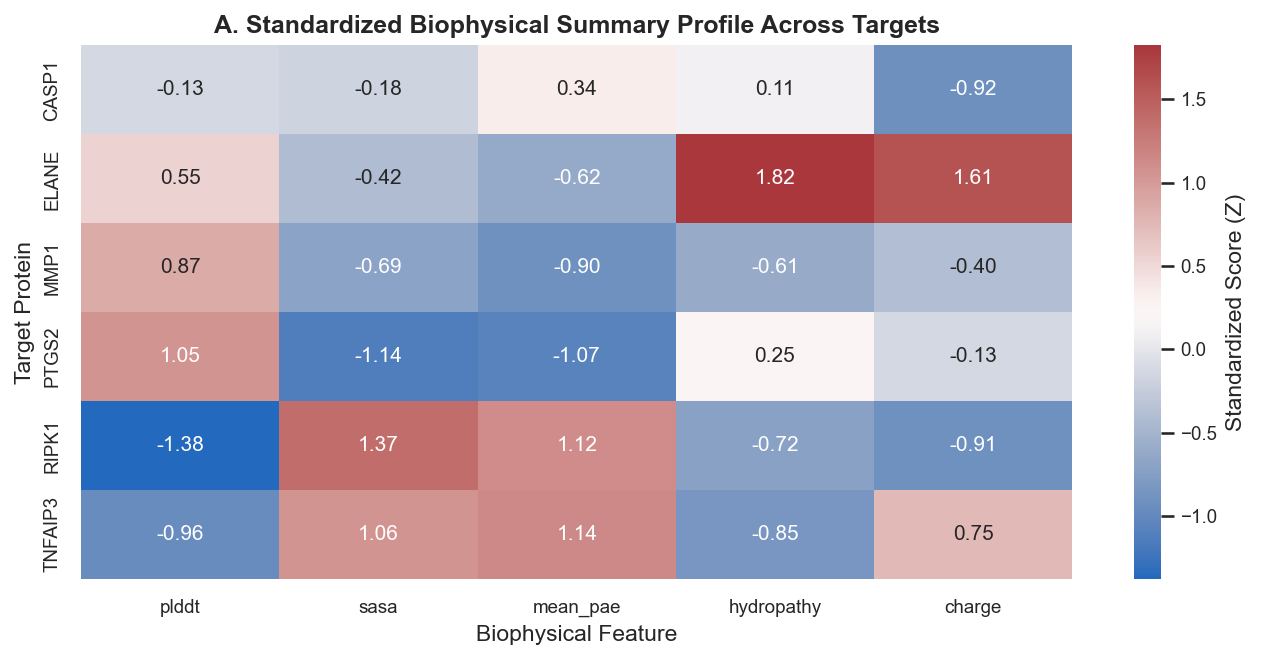

In [11]:
# Standardized summary statistics profile heatmap across targets
stats_for_heatmap = df_features.groupby("protein")[["plddt", "sasa", "mean_pae", "hydropathy", "charge"]].mean()
stats_zscore = (stats_for_heatmap - stats_for_heatmap.mean()) / stats_for_heatmap.std()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(stats_zscore, annot=True, fmt=".2f", cmap="vlag", ax=ax, cbar_kws={"label": "Standardized Score (Z)"})
ax.set_title("A. Standardized Biophysical Summary Profile Across Targets", fontweight="bold")
ax.set_xlabel("Biophysical Feature")
ax.set_ylabel("Target Protein")
plt.tight_layout()
plt.show()

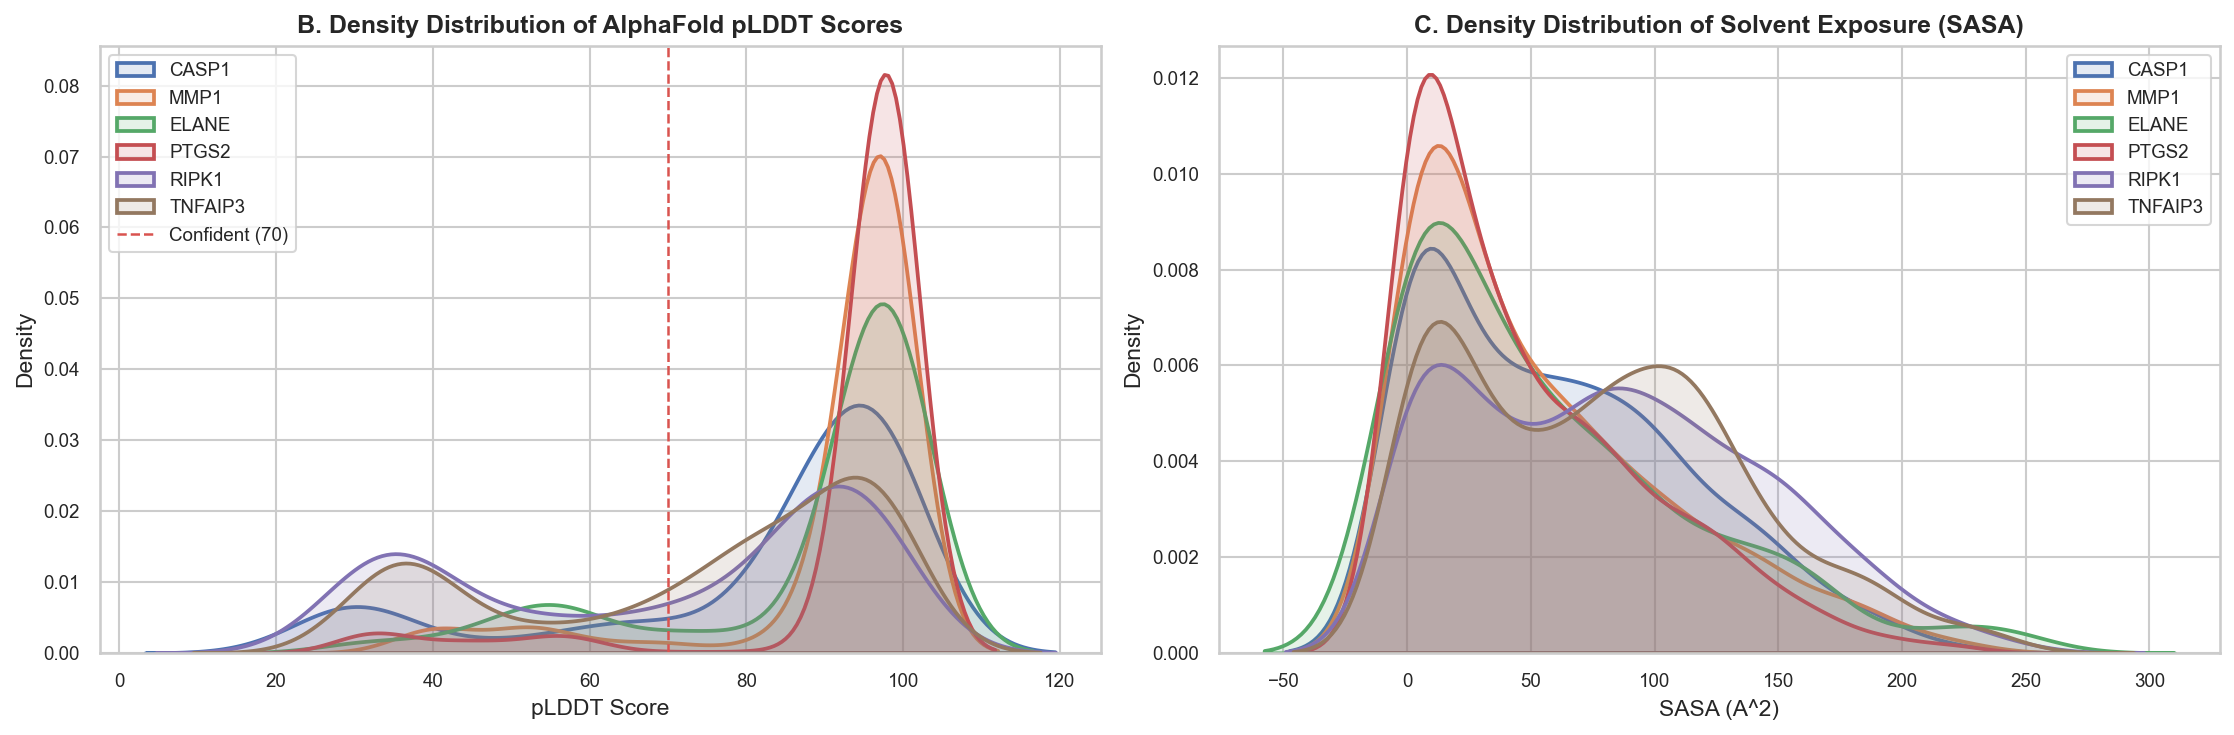

In [12]:
# Kernel density estimation distributions across enzymes
order = ["CASP1", "MMP1", "ELANE", "PTGS2", "RIPK1", "TNFAIP3"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for sym in order:
    subset = df_features[df_features["protein"] == sym]
    sns.kdeplot(data=subset["plddt"], ax=axes[0], label=sym, fill=True, alpha=0.15, linewidth=1.8)
    sns.kdeplot(data=subset["sasa"], ax=axes[1], label=sym, fill=True, alpha=0.15, linewidth=1.8)

axes[0].axvline(70.0, color="#d9534f", linestyle="--", linewidth=1.2, label="Confident (70)")
axes[0].set_title("B. Density Distribution of AlphaFold pLDDT Scores", fontweight="bold")
axes[0].set_xlabel("pLDDT Score")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper left")

axes[1].set_title("C. Density Distribution of Solvent Exposure (SASA)", fontweight="bold")
axes[1].set_xlabel("SASA (A^2)")
axes[1].set_ylabel("Density")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

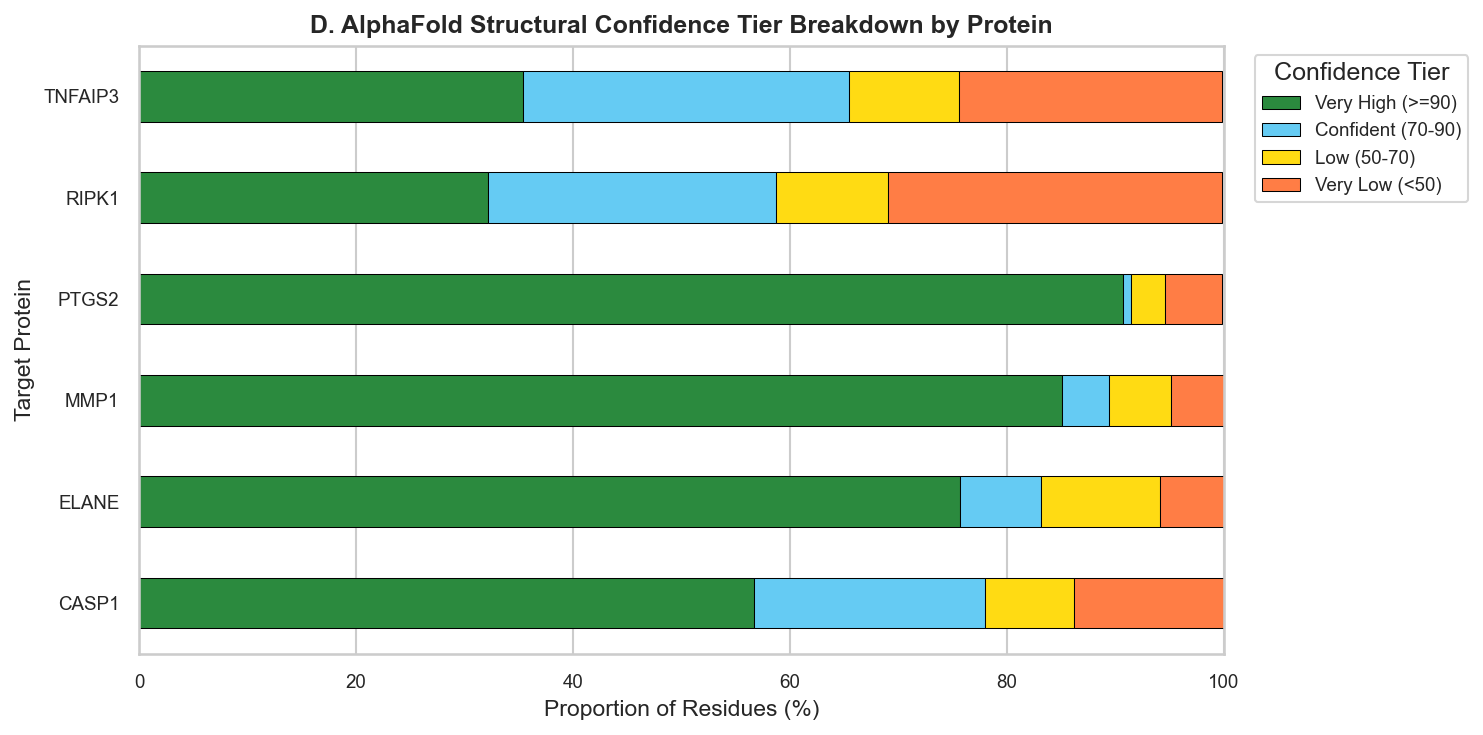

In [13]:
# Confidence tier percentage stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
tier_colors = ["#2b8a3e", "#65cbf3", "#ffdb13", "#ff7d45"]

tier_crosstab.plot(
    kind="barh", stacked=True, color=tier_colors, edgecolor="black", linewidth=0.5, ax=ax
)
ax.set_title("D. AlphaFold Structural Confidence Tier Breakdown by Protein", fontweight="bold")
ax.set_xlabel("Proportion of Residues (%)")
ax.set_ylabel("Target Protein")
ax.legend(title="Confidence Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

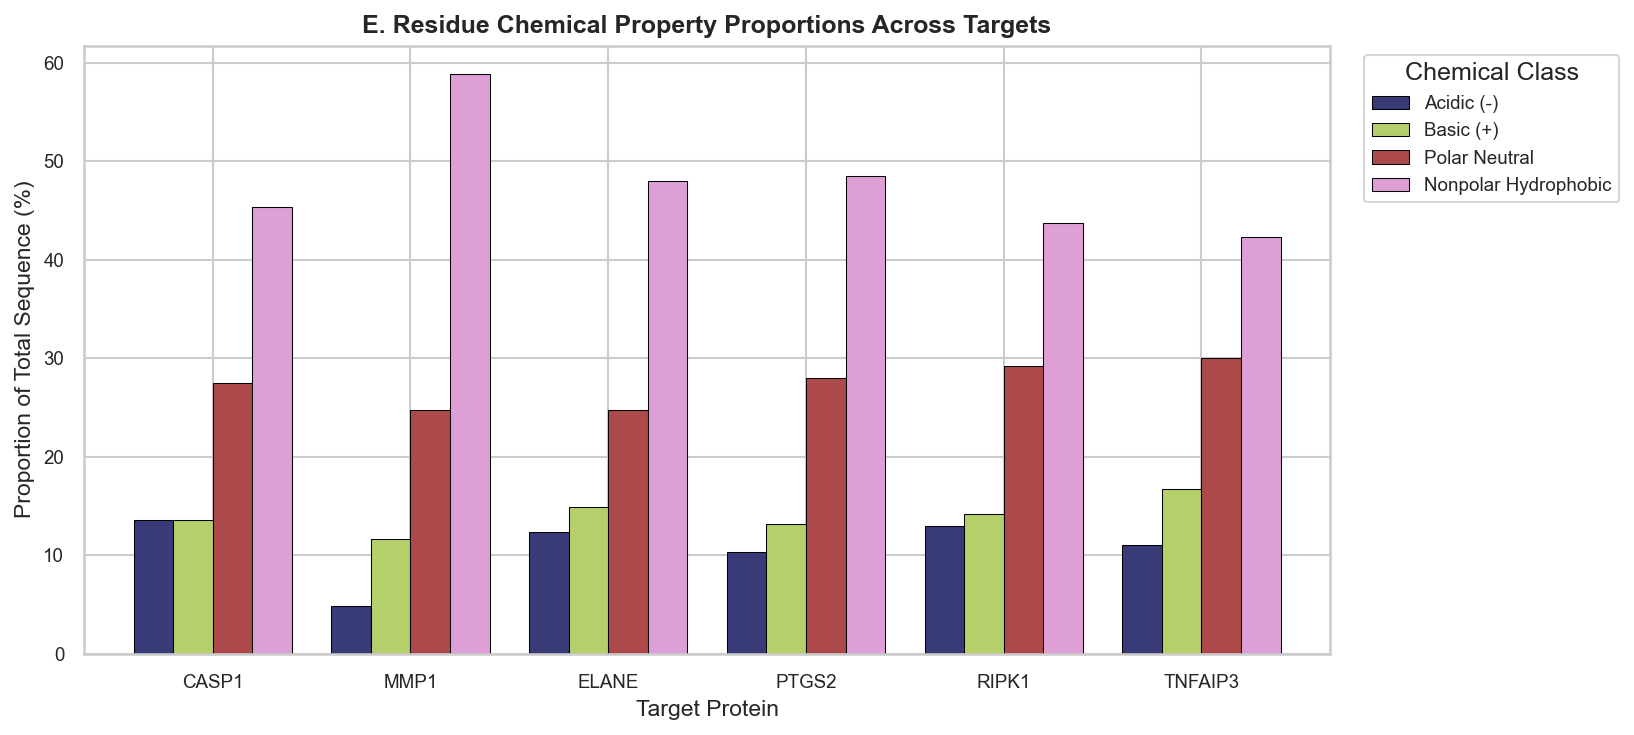

In [14]:
# Chemical classification frequency grouped bar chart
fig, ax = plt.subplots(figsize=(11, 5))
chem_crosstab.plot(kind="bar", width=0.8, colormap="tab20b", edgecolor="black", linewidth=0.5, ax=ax)
ax.set_title("E. Residue Chemical Property Proportions Across Targets", fontweight="bold")
ax.set_xlabel("Target Protein")
ax.set_ylabel("Proportion of Total Sequence (%)")
ax.legend(title="Chemical Class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(order, rotation=0)
plt.tight_layout()
plt.show()

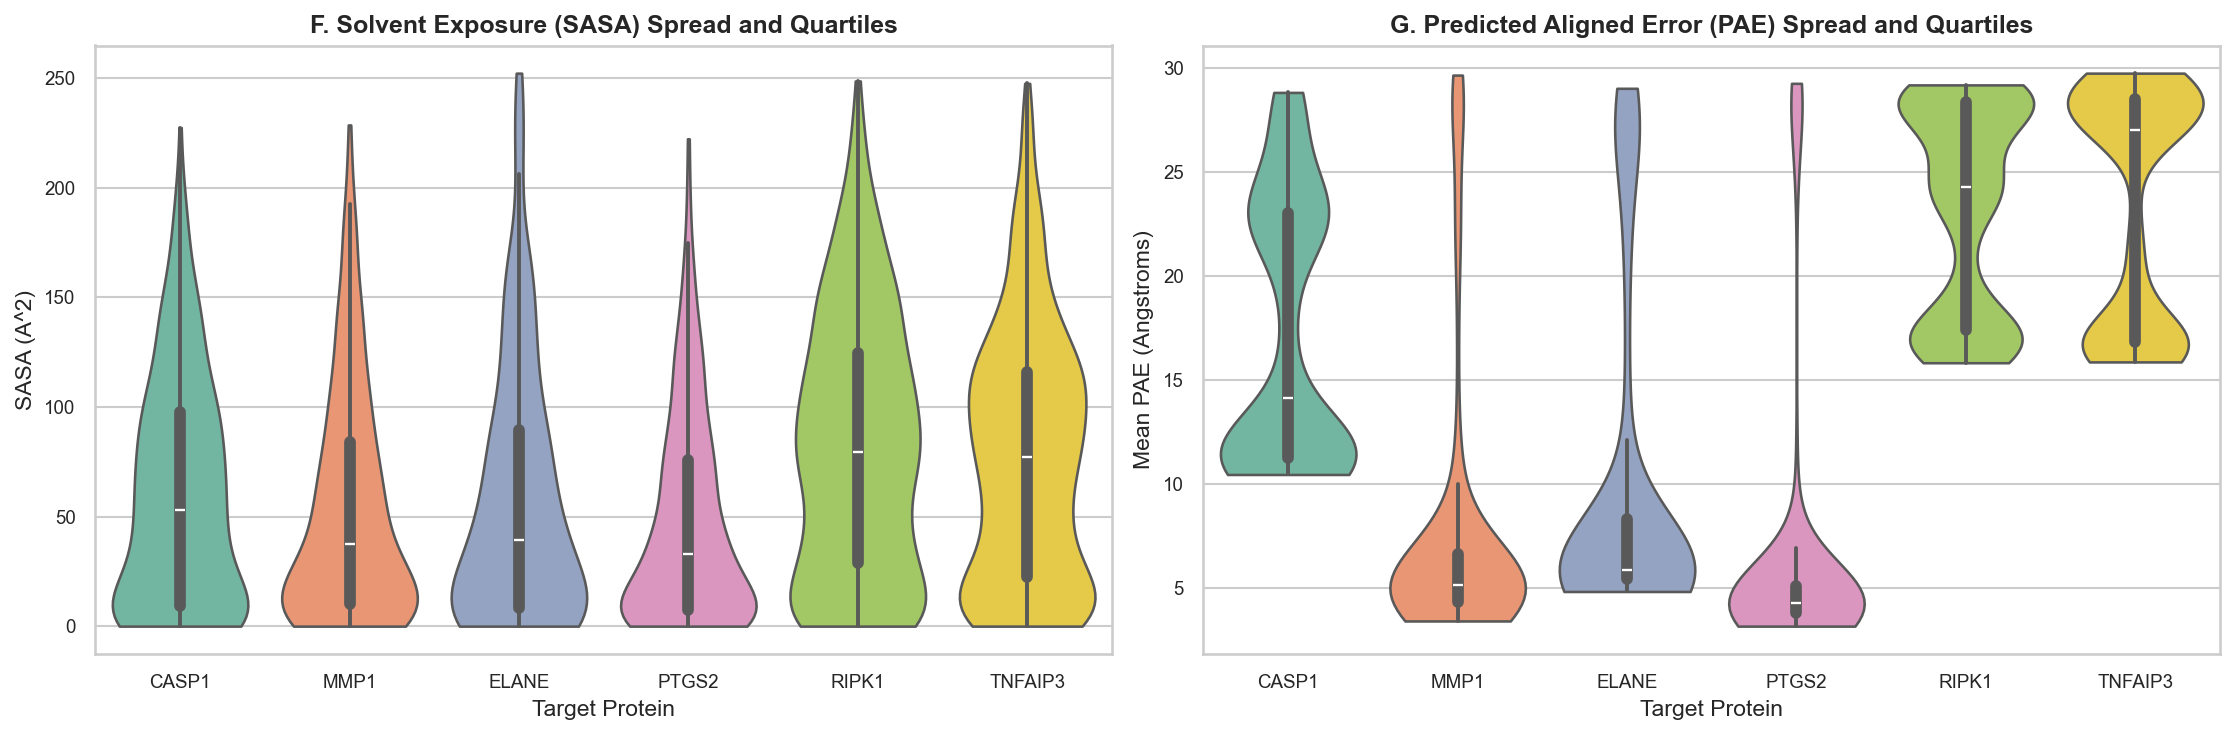

In [15]:
# Violin plot comparison of SASA and PAE distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(data=df_features, x="protein", y="sasa", order=order, palette="Set2", cut=0, ax=axes[0])
axes[0].set_title("F. Solvent Exposure (SASA) Spread and Quartiles", fontweight="bold")
axes[0].set_xlabel("Target Protein")
axes[0].set_ylabel("SASA (A^2)")

sns.violinplot(data=df_features, x="protein", y="mean_pae", order=order, palette="Set2", cut=0, ax=axes[1])
axes[1].set_title("G. Predicted Aligned Error (PAE) Spread and Quartiles", fontweight="bold")
axes[1].set_xlabel("Target Protein")
axes[1].set_ylabel("Mean PAE (Angstroms)")

plt.tight_layout()
plt.show()

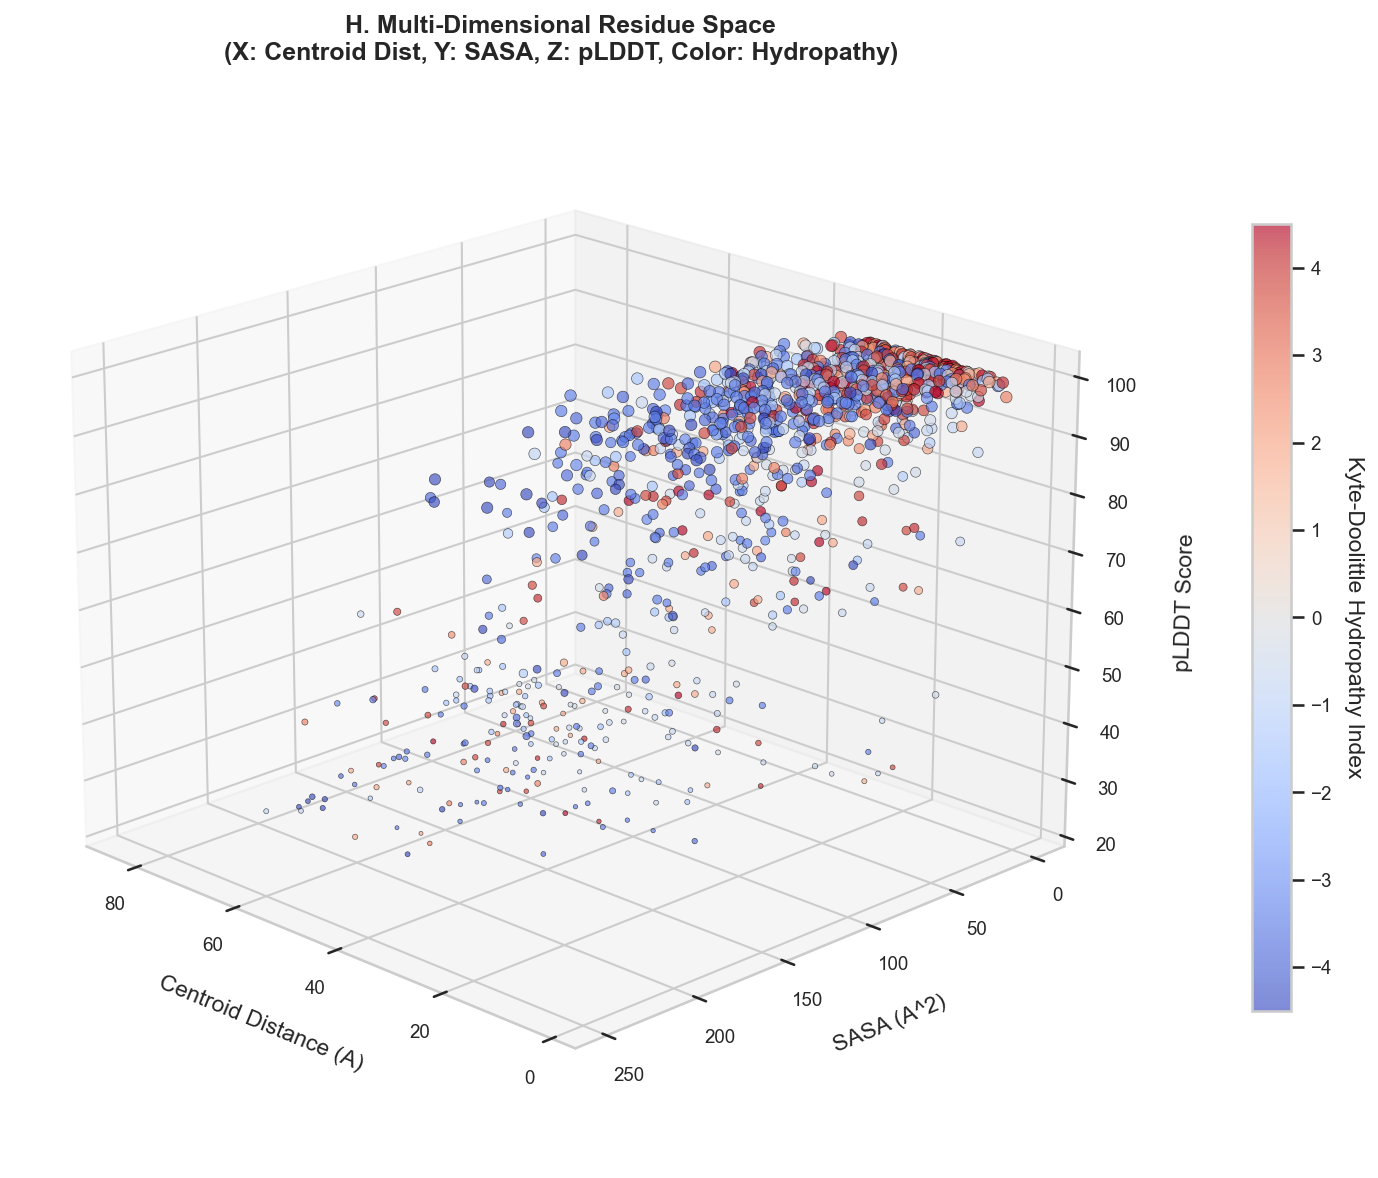

In [16]:
# Multi-dimensional 3D feature visualization (Distance, SASA, pLDDT, Hydropathy)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sample_df = df_features.sample(n=min(1200, len(df_features)), random_state=SEED)
plddt_scaled_size = (sample_df["plddt"] / 10.0) ** 1.5

scatter = ax.scatter(
    sample_df["dist_centroid"],
    sample_df["sasa"],
    sample_df["plddt"],
    c=sample_df["hydropathy"],
    cmap="coolwarm",
    s=plddt_scaled_size,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.3
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Kyte-Doolittle Hydropathy Index", rotation=270, labelpad=15)

ax.set_title("H. Multi-Dimensional Residue Space\n(X: Centroid Dist, Y: SASA, Z: pLDDT, Color: Hydropathy)", fontweight="bold")
ax.set_xlabel("Centroid Distance (A)", labelpad=10)
ax.set_ylabel("SASA (A^2)", labelpad=10)
ax.set_zlabel("pLDDT Score", labelpad=10)
ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()

### Step 6: Visualize enzyme-specific biophysical relationships and 3D molecular structure

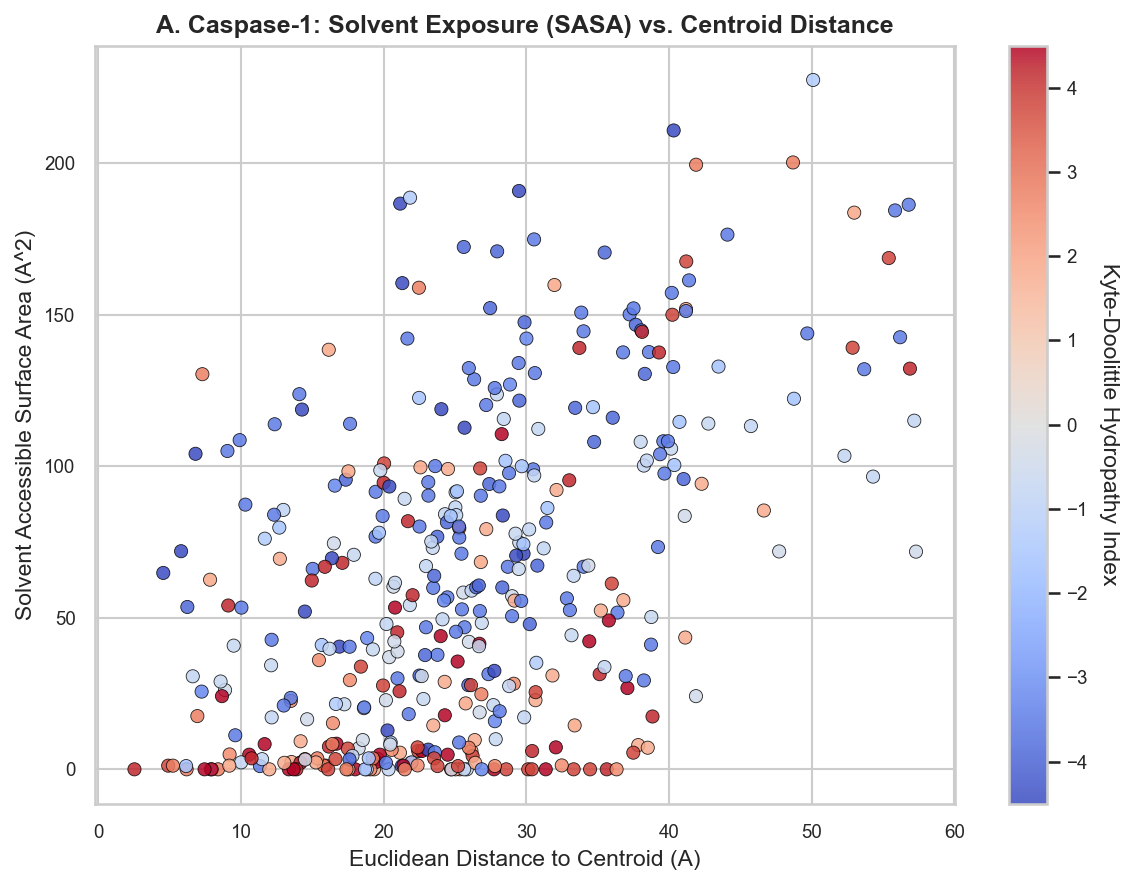

In [17]:
# Caspase-1 SASA vs Centroid Distance scatter plot
casp1_data = df_features[df_features["protein"] == "CASP1"].copy()

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    casp1_data["dist_centroid"], casp1_data["sasa"],
    c=casp1_data["hydropathy"], cmap="coolwarm", s=40,
    edgecolor="black", linewidth=0.4, alpha=0.85
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Kyte-Doolittle Hydropathy Index", rotation=270, labelpad=15)
ax.set_title("A. Caspase-1: Solvent Exposure (SASA) vs. Centroid Distance", fontweight="bold")
ax.set_xlabel("Euclidean Distance to Centroid (A)")
ax.set_ylabel("Solvent Accessible Surface Area (A^2)")
plt.tight_layout()
plt.show()

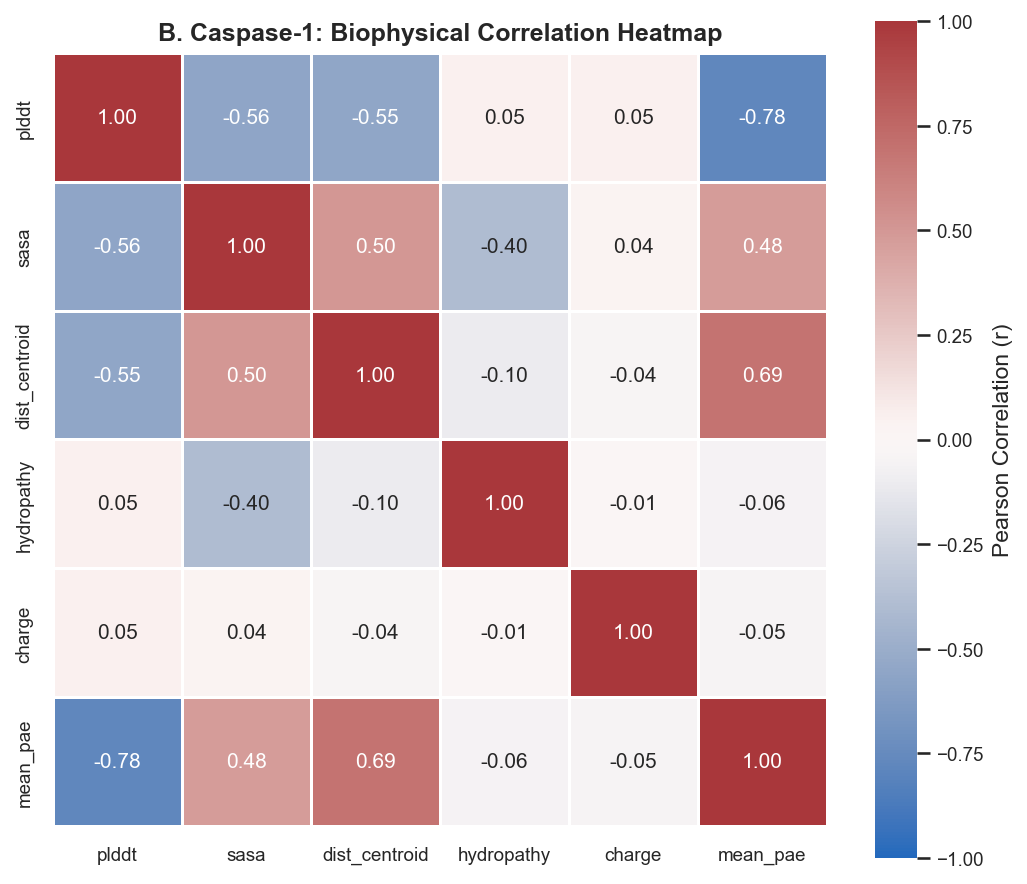

In [18]:
# Feature correlation heatmap for Caspase-1
fig, ax = plt.subplots(figsize=(7, 6))
casp1_corr = casp1_data[["plddt", "sasa", "dist_centroid", "hydropathy", "charge", "mean_pae"]].corr()
sns.heatmap(
    casp1_corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1.0, vmax=1.0,
    square=True, ax=ax, cbar_kws={"label": "Pearson Correlation (r)"},
    linewidths=0.5
)
ax.set_title("B. Caspase-1: Biophysical Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

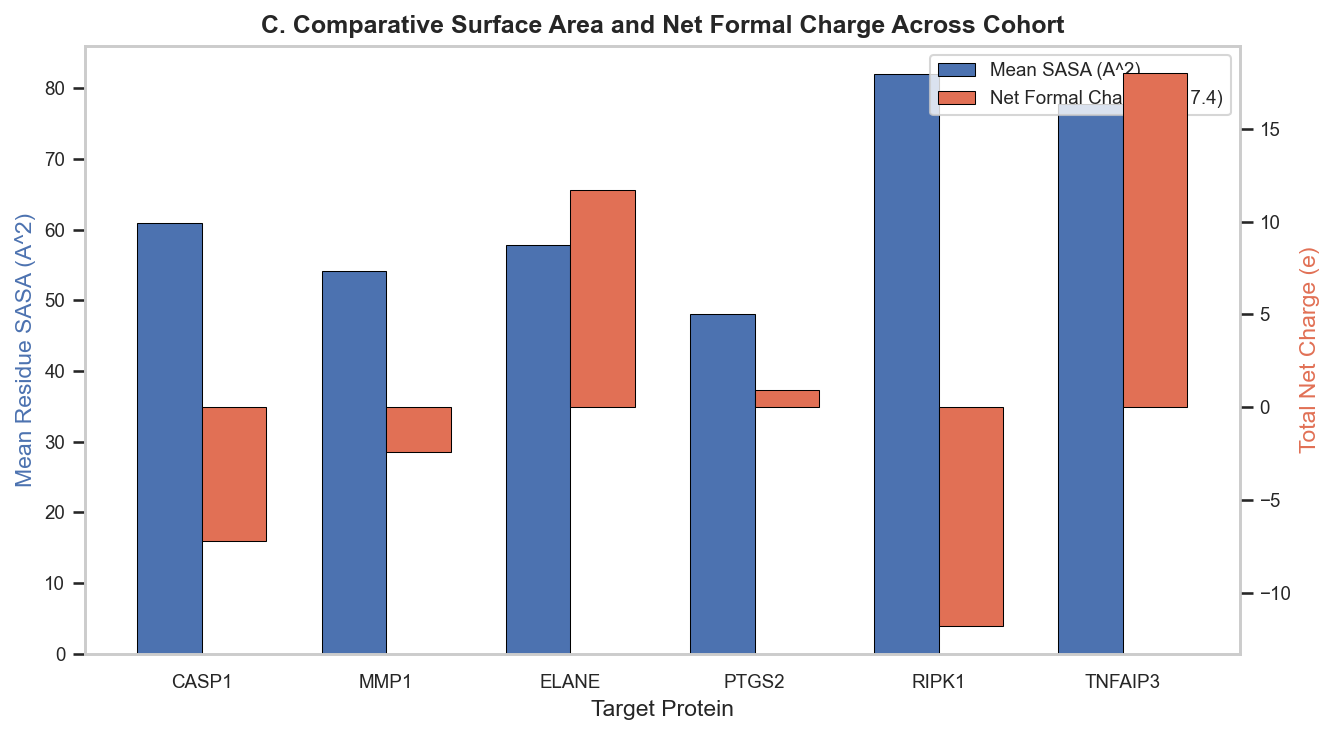

In [19]:
# Comparative bar chart of mean SASA and net formal charge
summary_metrics = df_features.groupby("protein").agg(
    mean_sasa=("sasa", "mean"),
    net_charge=("charge", "sum")
).reindex(order).reset_index()

fig, ax4 = plt.subplots(figsize=(9, 5))
x = np.arange(len(order))
width = 0.35

rects1 = ax4.bar(x - width/2, summary_metrics["mean_sasa"], width, label="Mean SASA (A^2)", color="#4c72b0", edgecolor="black", linewidth=0.5)
ax4_twin = ax4.twinx()
rects2 = ax4_twin.bar(x + width/2, summary_metrics["net_charge"], width, label="Net Formal Charge (pH 7.4)", color="#e17055", edgecolor="black", linewidth=0.5)

ax4.set_xticks(x)
ax4.set_xticklabels(order)
ax4.set_title("C. Comparative Surface Area and Net Formal Charge Across Cohort", fontweight="bold")
ax4.set_xlabel("Target Protein")
ax4.set_ylabel("Mean Residue SASA (A^2)", color="#4c72b0")
ax4_twin.set_ylabel("Total Net Charge (e)", color="#e17055")
ax4.grid(False)
ax4_twin.grid(False)

lines_1, labels_1 = ax4.get_legend_handles_labels()
lines_2, labels_2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [20]:
# 3D molecular visualization for Caspase-1 colored by pLDDT
casp1_pdb_path = dataset_manifest["CASP1"]["pdb_path"]
if HAS_PY3DMOL and os.path.exists(casp1_pdb_path):
    with open(casp1_pdb_path, "r", encoding="utf-8") as f:
        pdb_str = f.read()

    viewer = py3Dmol.view(width=750, height=450)
    viewer.addModel(pdb_str, "pdb")
    viewer.setStyle({"cartoon": {
        "colorscheme": {
            "prop": "b",
            "gradient": "roygb",
            "min": 50,
            "max": 95
        }
    }})
    viewer.zoomTo()
    viewer.show()
else:
    print(f"Caspase-1 structure cached at: {casp1_pdb_path}")
    print(f"Total residues: {len(casp1_data)} | Mean pLDDT: {casp1_data['plddt'].mean():.2f}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Step 7: Perform inferential hypothesis testing on surface residue hydropathy

In [21]:
# Define surface-exposed subset: SASA >= 20.0 A^2
SURFACE_SASA_CUTOFF = 20.0

mmp1_surf = df_features[(df_features["protein"] == "MMP1") & (df_features["sasa"] >= SURFACE_SASA_CUTOFF)]["hydropathy"].values
tnfaip3_surf = df_features[(df_features["protein"] == "TNFAIP3") & (df_features["sasa"] >= SURFACE_SASA_CUTOFF)]["hydropathy"].values

n1, n2 = len(mmp1_surf), len(tnfaip3_surf)
xbar1, xbar2 = np.mean(mmp1_surf), np.mean(tnfaip3_surf)
med1, med2 = np.median(mmp1_surf), np.median(tnfaip3_surf)
s1, s2 = np.std(mmp1_surf, ddof=1), np.std(tnfaip3_surf, ddof=1)
iqr1, iqr2 = stats.iqr(mmp1_surf), stats.iqr(tnfaip3_surf)

print(f"MMP1 Surface Residues:    n={n1}, Mean={xbar1:+.3f}, SD={s1:.3f}, Median={med1:+.3f}, IQR={iqr1:.3f}")
print(f"TNFAIP3 Surface Residues: n={n2}, Mean={xbar2:+.3f}, SD={s2:.3f}, Median={med2:+.3f}, IQR={iqr2:.3f}")

MMP1 Surface Residues:    n=306, Mean=-1.448, SD=2.715, Median=-1.600, IQR=3.100
TNFAIP3 Surface Residues: n=608, Mean=-1.251, SD=2.748, Median=-1.600, IQR=3.100


Shapiro-Wilk Normality Test:
  MMP1:    W=0.8398, p-value=3.8503e-17
  TNFAIP3: W=0.8742, p-value=9.5181e-22
Levene's Test for Homogeneity of Variances:
  Statistic=0.6852, p-value=0.4080 (Equal variances)


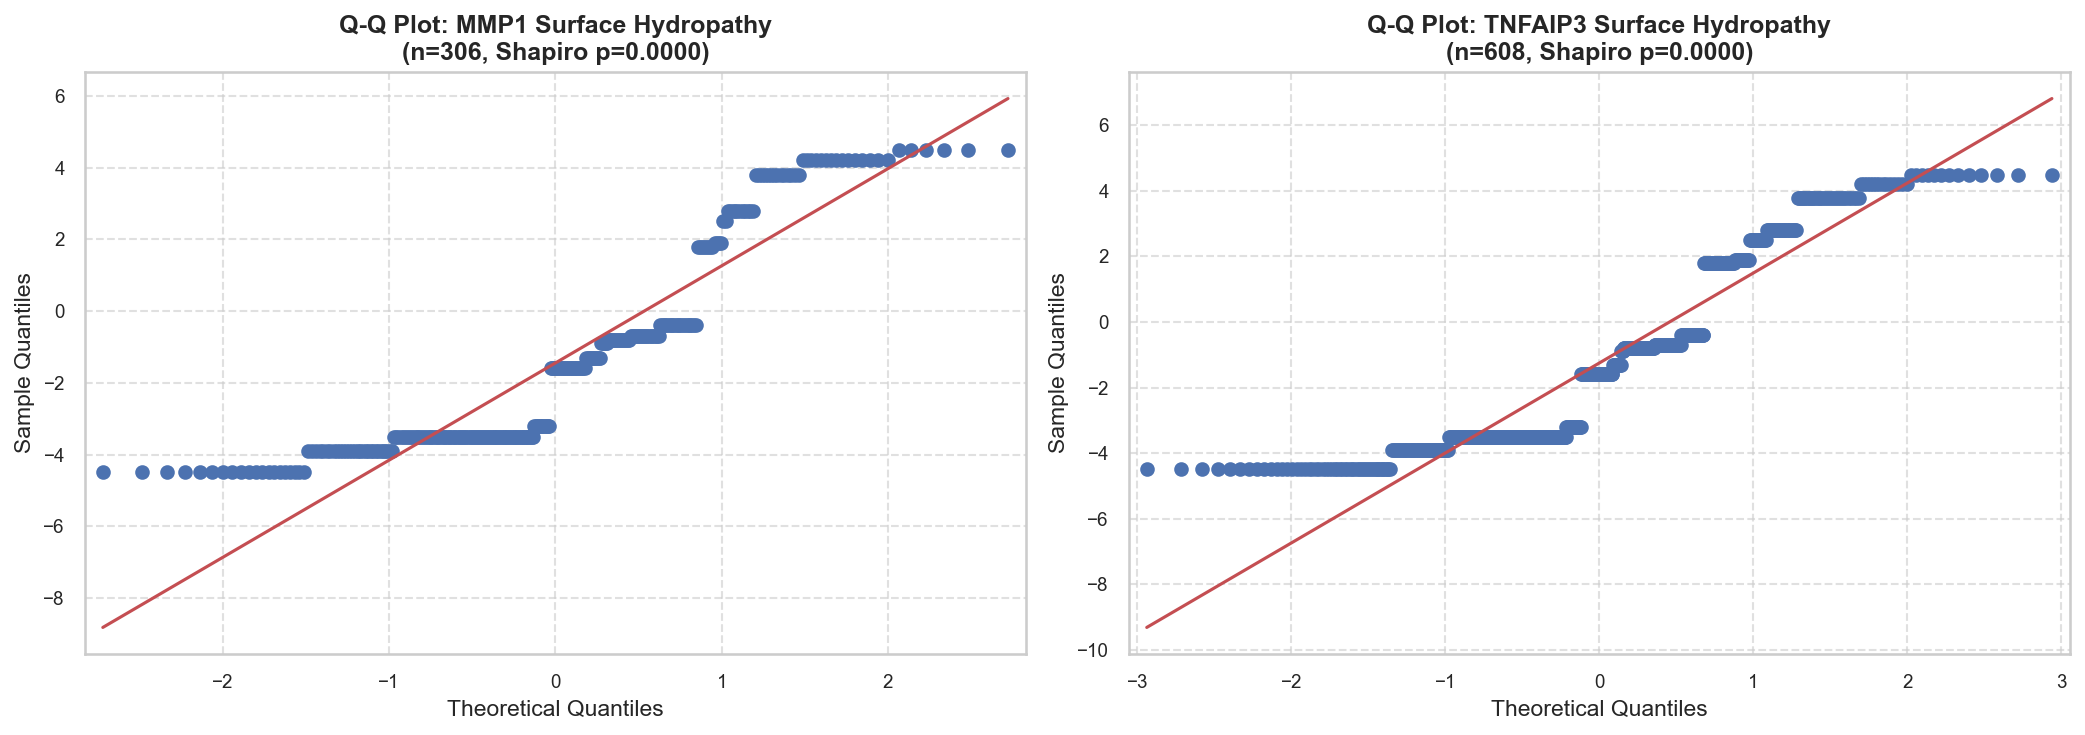

In [22]:
# Normality inspection and variance homogeneity tests
stat_sw1, p_sw1 = stats.shapiro(mmp1_surf)
stat_sw2, p_sw2 = stats.shapiro(tnfaip3_surf)

# Levene's test for equality of variances
stat_lev, p_lev = stats.levene(mmp1_surf, tnfaip3_surf, center="median")
print(f"Shapiro-Wilk Normality Test:")
print(f"  MMP1:    W={stat_sw1:.4f}, p-value={p_sw1:.4e}")
print(f"  TNFAIP3: W={stat_sw2:.4f}, p-value={p_sw2:.4e}")
print(f"Levene's Test for Homogeneity of Variances:")
print(f"  Statistic={stat_lev:.4f}, p-value={p_lev:.4f} ({'Equal' if p_lev > 0.05 else 'Unequal'} variances)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.qqplot(mmp1_surf, line="s", ax=axes[0])
axes[0].set_title(f"Q-Q Plot: MMP1 Surface Hydropathy\n(n={n1}, Shapiro p={p_sw1:.4f})", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

sm.qqplot(tnfaip3_surf, line="s", ax=axes[1])
axes[1].set_title(f"Q-Q Plot: TNFAIP3 Surface Hydropathy\n(n={n2}, Shapiro p={p_sw2:.4f})", fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
# Parametric Welch's two-sample t-test (unpooled variance)
diff_mean = xbar1 - xbar2
se_diff = np.sqrt((s1**2 / n1) + (s2**2 / n2))
t_stat = diff_mean / se_diff

# Welch-Satterthwaite degrees of freedom approximation
num_df = (s1**2 / n1 + s2**2 / n2)**2
den_df = ((s1**2 / n1)**2 / (n1 - 1)) + ((s2**2 / n2)**2 / (n2 - 1))
df_welch = num_df / den_df

p_val_welch = 2.0 * (1.0 - stats.t.cdf(np.abs(t_stat), df=df_welch))
alpha = 0.05
t_crit = stats.t.ppf(1.0 - alpha / 2.0, df=df_welch)
ci_lower = diff_mean - t_crit * se_diff
ci_upper = diff_mean + t_crit * se_diff

s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = diff_mean / s_pooled

print(f"Welch's Two-Sample t-test:")
print(f"  t-statistic: {t_stat:+.4f}, df: {df_welch:.2f}, p-value: {p_val_welch:.4e}")
print(f"  Difference in means: {diff_mean:+.3f} (SE: {se_diff:.4f})")
print(f"  95% Confidence Interval: [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"  Effect size (Cohen's d): {cohens_d:.3f}")

Welch's Two-Sample t-test:
  t-statistic: -1.0306, df: 618.14, p-value: 3.0315e-01
  Difference in means: -0.197 (SE: 0.1911)
  95% Confidence Interval: [-0.5721, +0.1783]
  Effect size (Cohen's d): -0.072


In [24]:
# Non-parametric tests: Mann-Whitney U and Kolmogorov-Smirnov
stat_mwu, p_val_mwu = stats.mannwhitneyu(mmp1_surf, tnfaip3_surf, alternative="two-sided")
stat_ks, p_val_ks = stats.ks_2samp(mmp1_surf, tnfaip3_surf)

print("Non-Parametric & Distributional Tests:")
print(f"  Mann-Whitney U Test:     U={stat_mwu:.1f}, p-value={p_val_mwu:.4e}")
print(f"  Kolmogorov-Smirnov Test: D={stat_ks:.4f}, p-value={p_val_ks:.4e}")
print(f"Conclusion: {'Significant difference' if p_val_mwu < 0.05 else 'No significant difference'} across non-parametric testing.")

Non-Parametric & Distributional Tests:
  Mann-Whitney U Test:     U=89965.5, p-value=4.1191e-01
  Kolmogorov-Smirnov Test: D=0.0617, p-value=3.9967e-01
Conclusion: No significant difference across non-parametric testing.


In [25]:
# Cohort-wide comparison: One-Way ANOVA and Kruskal-Wallis H-test
cohort_surf_groups = [
    df_features[(df_features["protein"] == sym) & (df_features["sasa"] >= SURFACE_SASA_CUTOFF)]["hydropathy"].values
    for sym in order
]

stat_f, p_val_anova = stats.f_oneway(*cohort_surf_groups)
stat_kw, p_val_kw = stats.kruskal(*cohort_surf_groups)

print("Cohort-Wide Surface Hydropathy Comparison (All 6 Enzymes):")
print(f"  One-Way ANOVA:          F={stat_f:.4f}, p-value={p_val_anova:.4e}")
print(f"  Kruskal-Wallis H-Test:  H={stat_kw:.4f}, p-value={p_val_kw:.4e}")

Cohort-Wide Surface Hydropathy Comparison (All 6 Enzymes):
  One-Way ANOVA:          F=2.3442, p-value=3.9163e-02
  Kruskal-Wallis H-Test:  H=8.5343, p-value=1.2914e-01


### Step 8: Fit multiple linear and regularized regression models for solvent accessibility

In [26]:
casp1_reg = df_features[df_features["protein"] == "CASP1"].copy()
feature_cols = ["dist_centroid", "hydropathy", "charge", "plddt", "mean_pae"]
target_col = "sasa"

X_raw = casp1_reg[feature_cols].copy()
y = casp1_reg[target_col].values
X_const = sm.add_constant(X_raw)

# Fit Ordinary Least Squares (OLS) regression
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     78.88
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.30e-57
Time:                        20:05:50   Log-Likelihood:                -2036.1
No. Observations:                 404   AIC:                             4084.
Df Residuals:                     398   BIC:                             4108.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           121.1370     18.086      6.698

In [27]:
# Collinearity diagnostics via Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["Predictor"] = X_raw.columns
vif_data["VIF"] = [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])]
vif_data["Status"] = vif_data["VIF"].apply(lambda v: "Pass (VIF < 5.0)" if v < 5.0 else "Warning (VIF >= 5.0)")

print("Variance Inflation Factor (VIF) Table:")
print(vif_data.to_string(index=False))

Variance Inflation Factor (VIF) Table:
    Predictor       VIF               Status
dist_centroid 12.753203 Warning (VIF >= 5.0)
   hydropathy  1.023498     Pass (VIF < 5.0)
       charge  1.004733     Pass (VIF < 5.0)
        plddt  3.417861     Pass (VIF < 5.0)
     mean_pae 12.664456 Warning (VIF >= 5.0)


In [28]:
# Standardized regularized regression: RidgeCV and LassoCV
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=SEED).fit(X_scaled, y)

coef_comparison = pd.DataFrame({
    "Predictor": feature_cols,
    "OLS_Unstandardized": ols_model.params[1:].values,
    "Ridge_Standardized": ridge_cv.coef_,
    "Lasso_Standardized": lasso_cv.coef_
})

print("Regression Coefficients Comparison (OLS vs. Ridge vs. Lasso):")
print(coef_comparison.to_string(index=False))
print(f"\nOptimal Ridge alpha: {ridge_cv.alpha_:.4f}, Lasso alpha: {lasso_cv.alpha_:.4f}")

Regression Coefficients Comparison (OLS vs. Ridge vs. Lasso):
    Predictor  OLS_Unstandardized  Ridge_Standardized  Lasso_Standardized
dist_centroid            1.316567           14.167639           12.242957
   hydropathy           -6.112130          -18.704473          -17.925698
       charge            6.954727            3.493698            2.523105
        plddt           -1.049970          -23.711790          -20.941770
     mean_pae           -0.577727           -3.699361           -0.000000

Optimal Ridge alpha: 0.0010, Lasso alpha: 0.9326


### Step 9: Generate regression residual and diagnostic plots

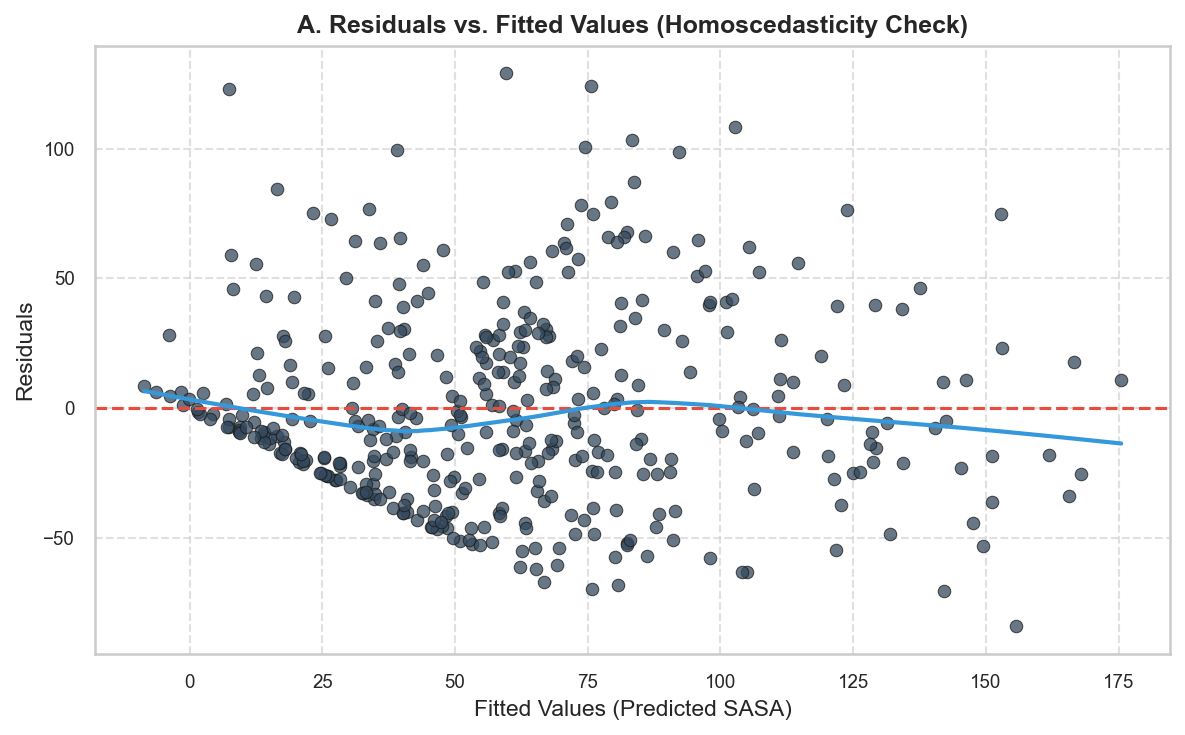

In [29]:
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

# Residuals vs. Fitted Values plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted_values, residuals, alpha=0.75, color="#34495e", edgecolor="k", linewidth=0.5)
ax.axhline(0.0, color="#e74c3c", linestyle="--", linewidth=1.5)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, ax=ax, line_kws={"color": "#3498db", "linewidth": 2.0})
ax.set_title("A. Residuals vs. Fitted Values (Homoscedasticity Check)", fontweight="bold")
ax.set_xlabel("Fitted Values (Predicted SASA)")
ax.set_ylabel("Residuals")
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

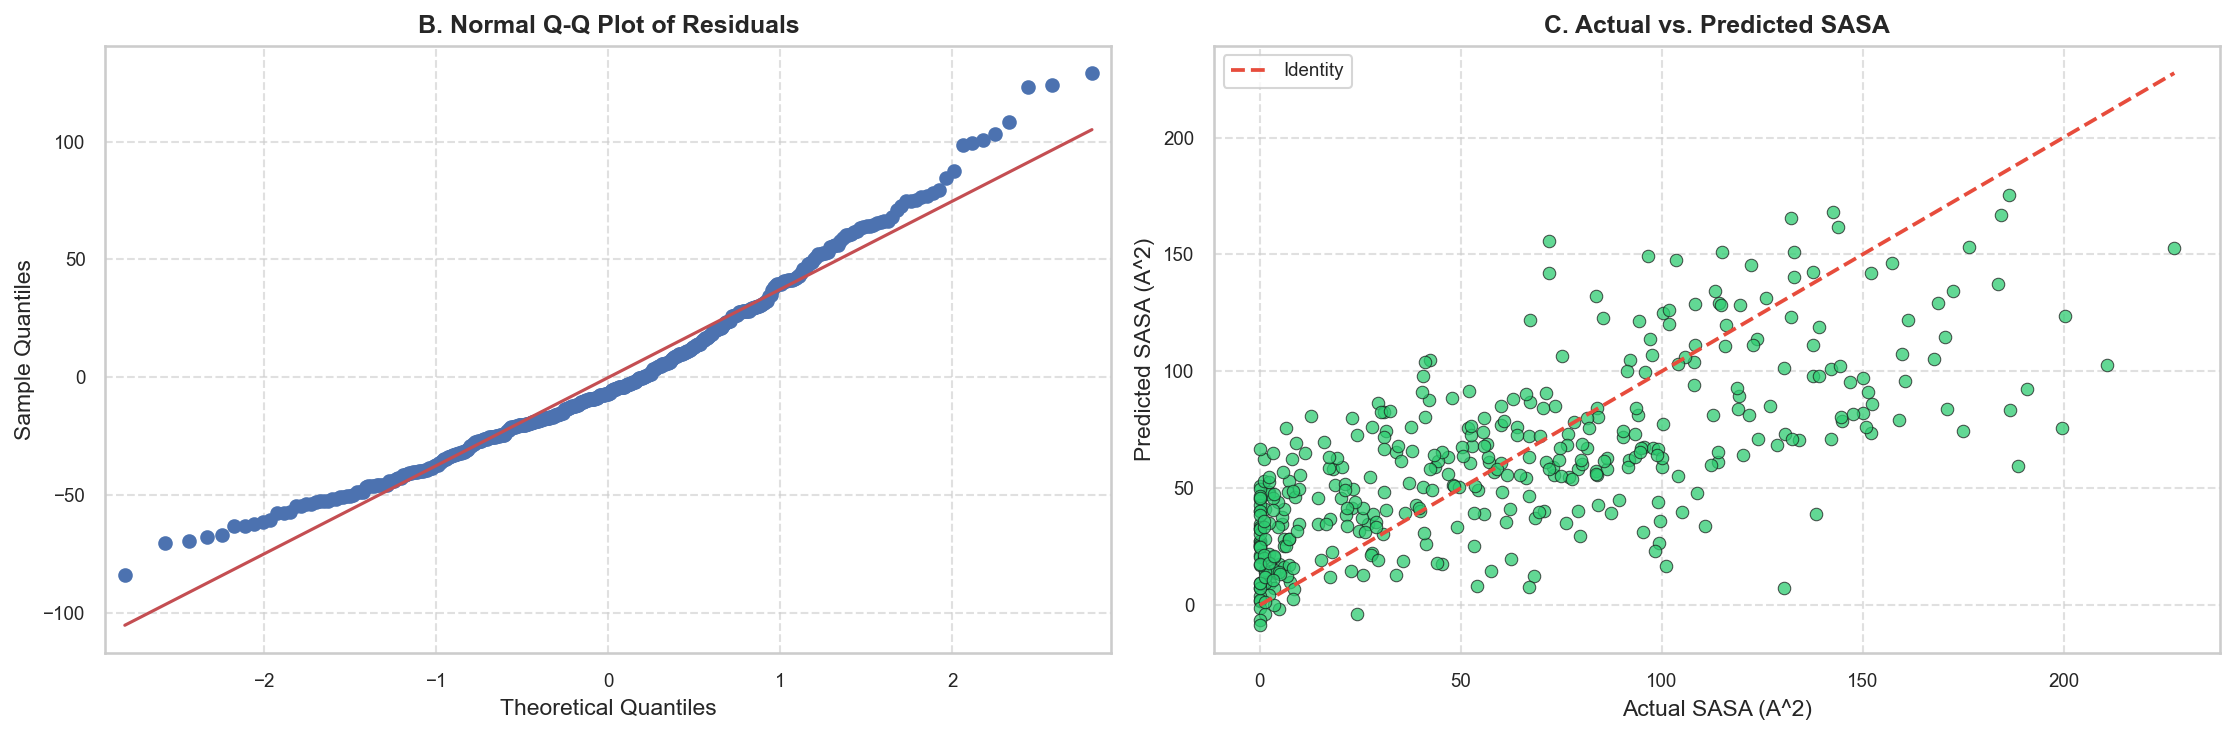

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Normal Q-Q plot of residuals
sm.qqplot(residuals, line="s", ax=axes[0])
axes[0].set_title("B. Normal Q-Q Plot of Residuals", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Actual vs. Predicted values
axes[1].scatter(y, fitted_values, alpha=0.75, color="#2ecc71", edgecolor="k", linewidth=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], color="#e74c3c", linestyle="--", linewidth=1.8, label="Identity")
axes[1].set_title("C. Actual vs. Predicted SASA", fontweight="bold")
axes[1].set_xlabel("Actual SASA (A^2)")
axes[1].set_ylabel("Predicted SASA (A^2)")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Step 10: Apply statistical model clustering, K-Means, and DBSCAN on latent features

In [31]:
cluster_features = ["dist_centroid", "hydropathy", "charge", "plddt", "sasa", "mean_pae"]
X_all = df_features[cluster_features].values

scaler_all = StandardScaler()
X_all_std = scaler_all.fit_transform(X_all)

# Principal Component Analysis
pca = PCA(n_components=len(cluster_features), random_state=SEED)
X_pca = pca.fit_transform(X_all_std)
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

for i, (ev, cv) in enumerate(zip(exp_var, cum_var), start=1):
    print(f"PC{i}: Explained Variance = {ev*100:5.2f}% | Cumulative = {cv*100:5.2f}%")

df_features["PC1"] = X_pca[:, 0]
df_features["PC2"] = X_pca[:, 1]

PC1: Explained Variance = 49.33% | Cumulative = 49.33%
PC2: Explained Variance = 19.26% | Cumulative = 68.59%
PC3: Explained Variance = 15.77% | Cumulative = 84.36%
PC4: Explained Variance =  6.79% | Cumulative = 91.15%
PC5: Explained Variance =  5.68% | Cumulative = 96.84%
PC6: Explained Variance =  3.16% | Cumulative = 100.00%


In [32]:
# Statistical clustering: Gaussian Mixture Models (GMM) with BIC evaluation
bic_scores = []
n_components_range = range(2, 7)

for k in n_components_range:
    gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=3)
    gmm.fit(X_pca[:, :3])
    bic_scores.append(gmm.bic(X_pca[:, :3]))

best_k_gmm = list(n_components_range)[np.argmin(bic_scores)]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=SEED, n_init=3)
df_features["gmm_cluster"] = best_gmm.fit_predict(X_pca[:, :3])

sil_gmm = silhouette_score(X_pca[:, :3], df_features["gmm_cluster"])
print(f"GMM optimal components by BIC: {best_k_gmm} | Silhouette Score: {sil_gmm:.3f}")

GMM optimal components by BIC: 6 | Silhouette Score: 0.361


In [33]:
# Centroid-based clustering: K-Means with inertia and silhouette evaluation
inertias = []
sil_kmeans_scores = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca[:, :3])
    inertias.append(km.inertia_)
    sil_kmeans_scores.append(silhouette_score(X_pca[:, :3], labels))

best_k_kmeans = list(k_range)[np.argmax(sil_kmeans_scores)]
best_kmeans = KMeans(n_clusters=best_k_kmeans, random_state=SEED, n_init=10)
df_features["kmeans_cluster"] = best_kmeans.fit_predict(X_pca[:, :3])

print(f"K-Means optimal k by Silhouette: {best_k_kmeans} | Silhouette Score: {max(sil_kmeans_scores):.3f}")

K-Means optimal k by Silhouette: 6 | Silhouette Score: 0.437


In [34]:
# Density-based clustering: t-SNE manifold learning and DBSCAN
tsne = TSNE(n_components=2, perplexity=35, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca[:, :3])

df_features["tSNE1"] = X_tsne[:, 0]
df_features["tSNE2"] = X_tsne[:, 1]

dbscan = DBSCAN(eps=2.8, min_samples=25)
df_features["dbscan_cluster"] = dbscan.fit_predict(X_tsne)

n_db_clusters = len(set(df_features["dbscan_cluster"])) - (1 if -1 in df_features["dbscan_cluster"].values else 0)
n_noise = int((df_features["dbscan_cluster"] == -1).sum())
print(f"DBSCAN clusters: {n_db_clusters}, noise points: {n_noise}")

DBSCAN clusters: 36, noise points: 350


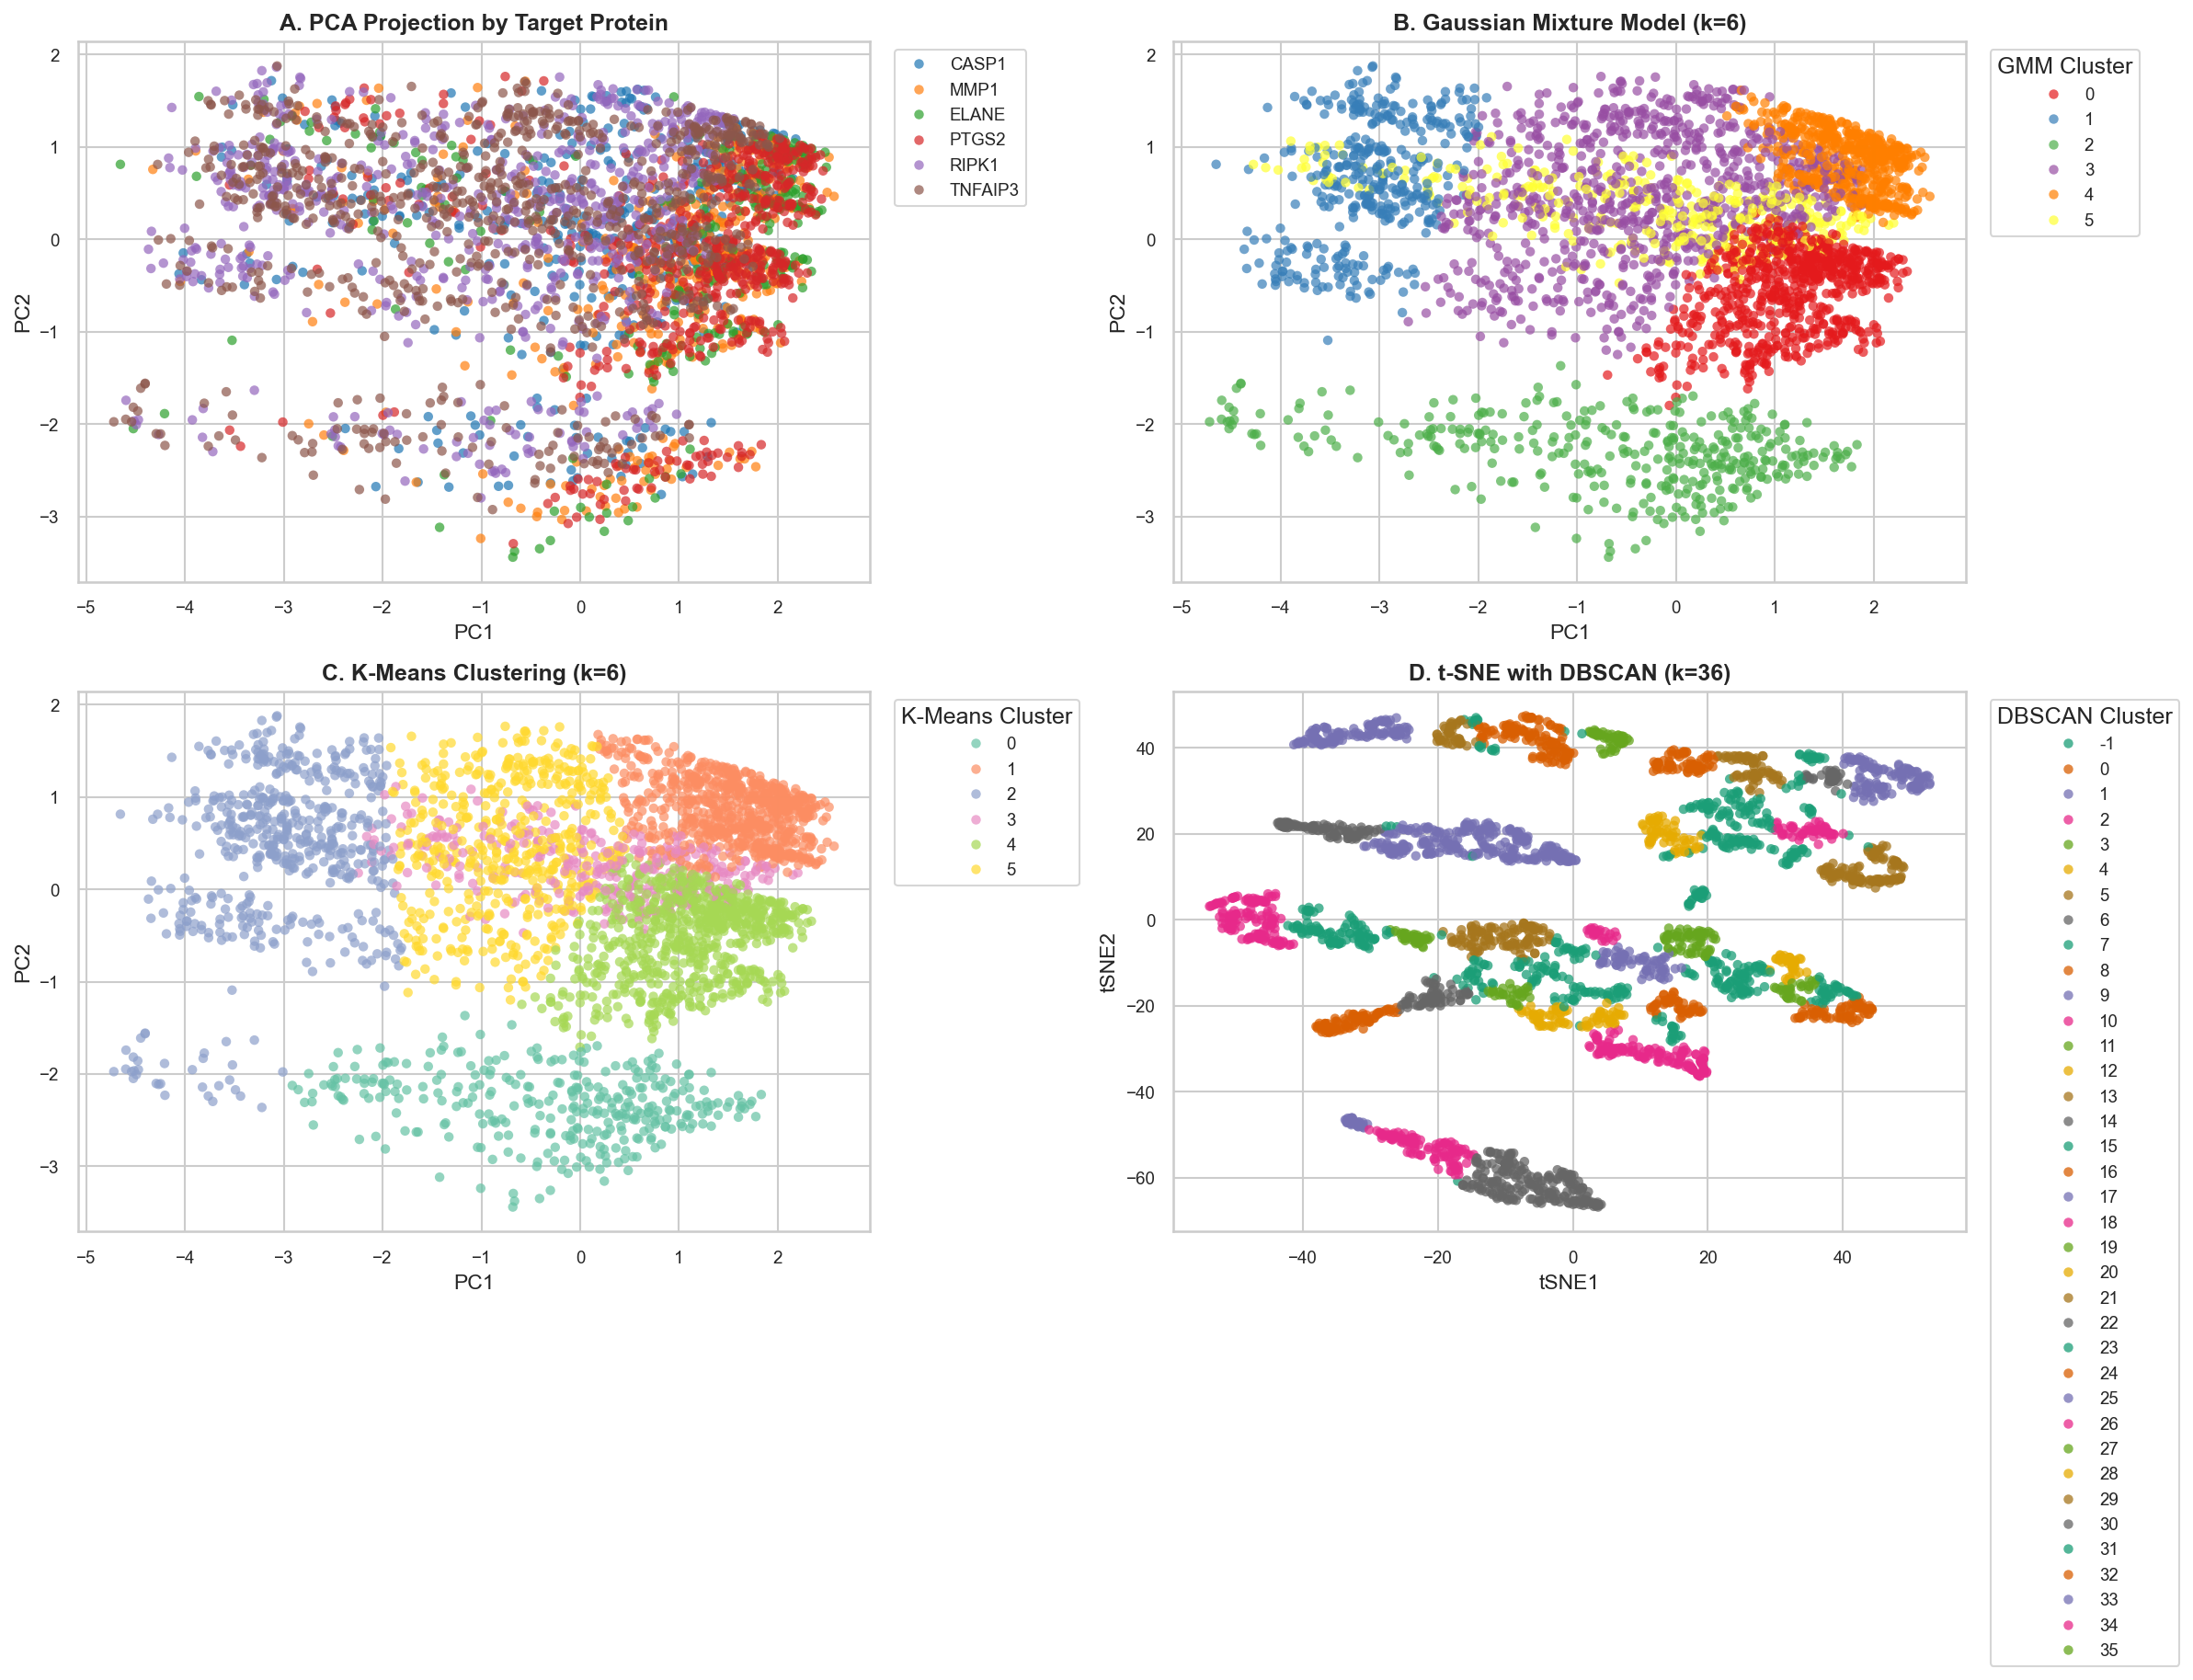

In [35]:
# Visual comparison: PCA, GMM, K-Means, and DBSCAN
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PCA by Protein
sns.scatterplot(
    data=df_features, x="PC1", y="PC2", hue="protein",
    palette="tab10", alpha=0.7, s=25, ax=axes[0, 0], edgecolor="none"
)
axes[0, 0].set_title("A. PCA Projection by Target Protein", fontweight="bold")
axes[0, 0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

# 2. GMM Clusters
sns.scatterplot(
    data=df_features, x="PC1", y="PC2", hue="gmm_cluster",
    palette="Set1", alpha=0.7, s=25, ax=axes[0, 1], edgecolor="none"
)
axes[0, 1].set_title(f"B. Gaussian Mixture Model (k={best_k_gmm})", fontweight="bold")
axes[0, 1].legend(title="GMM Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3. K-Means Clusters
sns.scatterplot(
    data=df_features, x="PC1", y="PC2", hue="kmeans_cluster",
    palette="Set2", alpha=0.7, s=25, ax=axes[1, 0], edgecolor="none"
)
axes[1, 0].set_title(f"C. K-Means Clustering (k={best_k_kmeans})", fontweight="bold")
axes[1, 0].legend(title="K-Means Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 4. DBSCAN Clusters
sns.scatterplot(
    data=df_features, x="tSNE1", y="tSNE2", hue="dbscan_cluster",
    palette="Dark2", alpha=0.75, s=25, ax=axes[1, 1], edgecolor="none"
)
axes[1, 1].set_title(f"D. t-SNE with DBSCAN (k={n_db_clusters})", fontweight="bold")
axes[1, 1].legend(title="DBSCAN Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [36]:
# Cluster biophysical profiles and enzyme membership distributions
print("K-Means Cluster Profiles (Mean Values):")
kmeans_profiles = df_features.groupby("kmeans_cluster")[cluster_features].mean().round(2)
kmeans_counts = df_features["kmeans_cluster"].value_counts().rename("Residues")
print(pd.concat([kmeans_counts, kmeans_profiles], axis=1).sort_index().to_string())

print("\nEnzyme Membership Across K-Means Clusters:")
crosstab_km = pd.crosstab(df_features["protein"], df_features["kmeans_cluster"])
print(crosstab_km.to_string())

print("\nEnzyme Membership Across DBSCAN Clusters:")
crosstab_db = pd.crosstab(df_features["protein"], df_features["dbscan_cluster"])
print(crosstab_db.to_string())

K-Means Cluster Profiles (Mean Values):
                Residues  dist_centroid  hydropathy  charge  plddt    sasa  mean_pae
kmeans_cluster                                                                      
0                    330          25.91       -4.18    0.99  88.26  104.55     14.89
1                    747          19.80        3.37    0.00  95.99   16.52      9.89
2                    532          52.34       -0.74   -0.01  38.95  136.83     28.63
3                    321          25.60       -3.50   -1.00  87.89   74.95     14.61
4                    762          21.47       -1.65    0.01  95.87   41.90      8.51
5                    513          31.82        0.39    0.00  73.57   68.87     24.48

Enzyme Membership Across K-Means Clusters:
kmeans_cluster   0    1    2   3    4    5
protein                                   
CASP1           47  103   46  52   84   72
ELANE           22  100   24  13   90   18
MMP1            56  133   25  57  178   20
PTGS2           58  1